---
title: "ML AI"
date: "2023-07-12"
description: Notes on LLM
image: profilea.jpg
---


# Assignment 2 by: Ajeet Singh (s4098655)


# Task 1: Regression


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import itertools
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,silhouette_score, davies_bouldin_score,calinski_harabasz_score, mean_squared_error, r2_score
from sklearn.utils import shuffle
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA




data = pd.read_csv('A2data.csv', sep = ';')
data.drop_duplicates()
data.replace(r'^\s*$', np.nan, regex=True, inplace=True) #Replacing white space with nan https://stackoverflow.com/a/47810911

In [2]:
data.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar           object
chlorides               float64
free sulfur dioxide      object
total sulfur dioxide     object
density                  object
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

In [3]:
data.isnull().sum()

fixed acidity           0
volatile acidity        1
citric acid             5
residual sugar          7
chlorides               1
free sulfur dioxide     4
total sulfur dioxide    4
density                 8
pH                      1
sulphates               2
alcohol                 0
quality                 0
dtype: int64

In [4]:
sample1=data[~data.isnull().any(axis=1)].sample(n=400,random_state=42) #selecting rows without null values
sample1.to_csv('s4098655-A2SampleOne.csv',sep=';',index=False)
sample1 = pd.read_csv('s4098655-A2SampleOne.csv', sep = ';')
sample1= sample1.apply(pd.to_numeric)

In [5]:
sample1.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.5,0.19,0.49,1.6,0.047,42.0,140.0,0.99320,3.40,0.47,10.7,6
1,6.6,0.16,0.34,1.1,0.037,41.0,115.0,0.98990,3.01,0.68,12.0,6
2,6.7,0.21,0.42,9.1,0.049,31.0,150.0,0.99530,3.12,0.74,9.9,7
3,7.0,0.16,0.36,2.6,0.029,28.0,98.0,0.99126,3.11,0.37,11.2,7
4,6.4,0.24,0.27,1.5,0.040,35.0,105.0,0.98914,3.13,0.30,12.4,6


In [6]:
sample1.isnull().sum() #checking once again

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

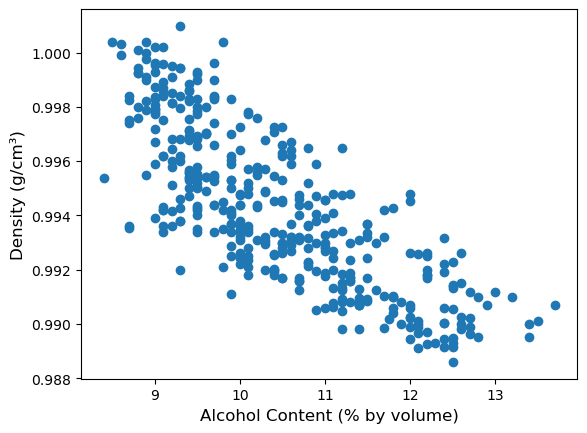

In [7]:
#Scatter plot to find the relatinship between alcohol and density.
plt.scatter(sample1['alcohol'],sample1['density'])
plt.xlabel('Alcohol Content (% by volume)', fontsize=12)
plt.ylabel('Density (g/cm³)', fontsize=12)
plt.show()

In [8]:
X = pd.DataFrame(sample1['density'])  # Density is the independent variable
y = pd.DataFrame(sample1['alcohol'])
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=0.3,random_state=42)

In [9]:
reg = LinearRegression().fit(X_train,y_train)
# Predict the values for the test set
y_pred = reg.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")
slope = reg.coef_
intercept = reg.intercept_

print(f"Slope (coefficient): {slope}")
print(f"Intercept: {intercept}")

Mean Squared Error (MSE): 0.5584523695518155
R-squared (R2): 0.6289517388697186
Slope (coefficient): [[-313.9334083]]
Intercept: [322.53048828]


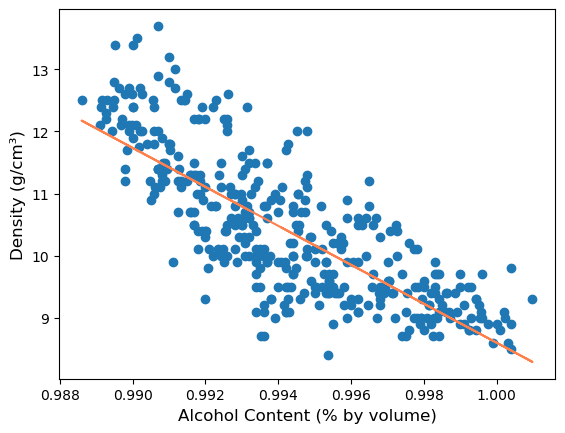

In [10]:
#PLot with linear model
plt.scatter(X, y)
plt.plot(X, reg.predict(X), color =(1,0.5,0.3) )
plt.ylabel('Density (g/cm³)', fontsize=12)
plt.xlabel('Alcohol Content (% by volume)', fontsize=12)
plt.show()

# Task 2: Classification

In [11]:
# For each Task, you may choose to or not to use subsections.
# Feel free to add new subsections under any Task or delete/amend any subsections (e.g. kNN) in this template.
sample2=data[~data.isnull().any(axis=1)].sample(1000,random_state=40)
sample2.to_csv('s4098655-A2SampleTwo.csv',sep=';',index=False)
sample2 = pd.read_csv('s4098655-A2SampleOne.csv', sep = ';')
sample2 = sample2.apply(pd.to_numeric)

In [12]:
sample2.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [13]:
X = pd.DataFrame(sample2.drop(columns=['quality']))  # Features (all columns except quality)
y = pd.DataFrame(sample2['quality'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)


## kNN

Max accuracy is: 0.4875 For k= 2


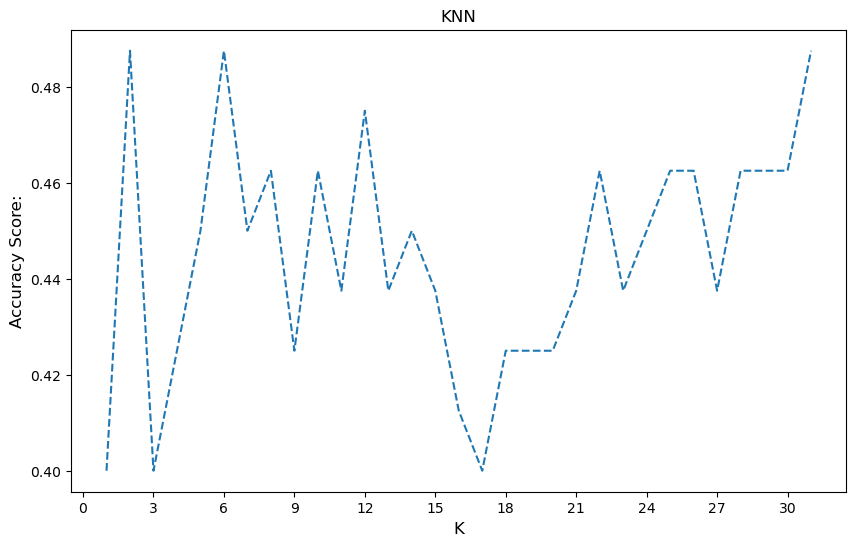

In [14]:
error=[]
max_accu=0
k_max=0
for k in range(1,32): #looping till sqrt(1000)
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train.values.flatten())
    y_pred_knn = knn.predict(X_test)
    accuracy_knn = accuracy_score(y_test, y_pred_knn)
    error.append(accuracy_knn)
    if(max_accu<accuracy_knn):
        k_max=k
    max_accu=max(accuracy_knn,max_accu)
print("Max accuracy is:",max_accu,"For k=",k_max)
#plotting the score vs k
plt.figure(figsize=(10,6))
plt.plot(range(1,32),error,linestyle='dashed')
ticks=np.arange(0, 32, 3)
plt.xticks(ticks)
plt.ylabel('Accuracy Score:', fontsize=12)
plt.xlabel('K', fontsize=12)
plt.title('KNN')
plt.show()


In [15]:
knn = KNeighborsClassifier(n_neighbors=k_max) #chossing the best k
knn.fit(X_train, y_train.values.flatten())
y_pred_knn = knn.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy of kNN classifier: {accuracy_knn:.4f}")
print("\nClassification Report for kNN:")
print(classification_report(y_test, y_pred_knn,zero_division=0))

# Confusion Matrix
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
print("Confusion Matrix for kNN:")
print(conf_matrix_knn)

Accuracy of kNN classifier: 0.4875

Classification Report for kNN:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         3
           5       0.59      0.75      0.66        32
           6       0.40      0.50      0.44        28
           7       1.00      0.08      0.15        12
           8       0.00      0.00      0.00         4

    accuracy                           0.49        80
   macro avg       0.33      0.22      0.21        80
weighted avg       0.52      0.49      0.44        80

Confusion Matrix for kNN:
[[ 0  0  1  0  0  0]
 [ 0  0  2  1  0  0]
 [ 0  1 24  7  0  0]
 [ 0  2 12 14  0  0]
 [ 0  0  2  9  1  0]
 [ 0  0  0  4  0  0]]


## modified kNN 

In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Max accuracy is: 0.525 For k= 13


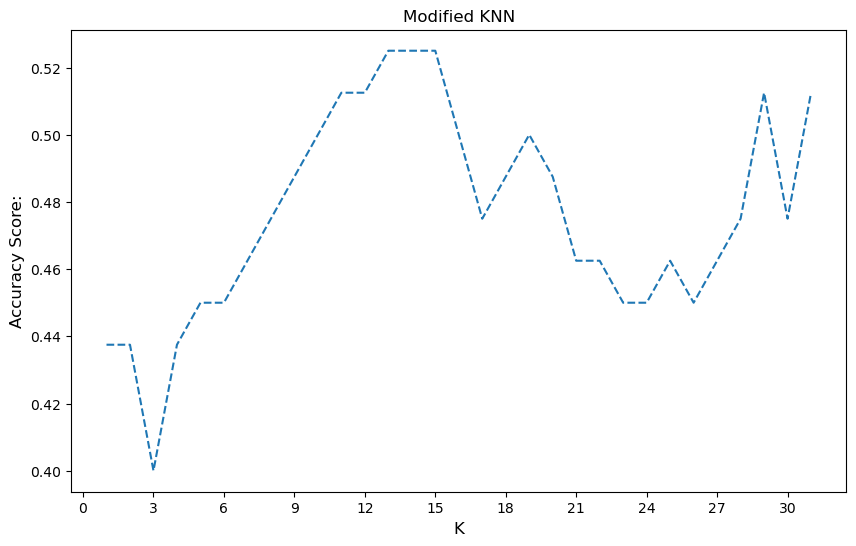

In [17]:
error=[]
max_accu=0
k_max=0
for k in range(1,32):
    knn_modified = KNeighborsClassifier(n_neighbors=k,weights='distance',p=1)
    knn_modified.fit(X_train, y_train.values.flatten())
    y_pred_knn = knn_modified.predict(X_test)
    accuracy_knn_modified = accuracy_score(y_test, y_pred_knn)
    if(max_accu<accuracy_knn_modified):
        k_max=k
    max_accu=max(accuracy_knn_modified,max_accu)
    error.append(accuracy_knn_modified)
print("Max accuracy is:",max_accu,"For k=",k_max)

plt.figure(figsize=(10,6))
plt.plot(range(1,32),error,linestyle='dashed')
ticks=np.arange(0, 32, 3)
plt.xticks(ticks)
plt.ylabel('Accuracy Score:', fontsize=12)
plt.xlabel('K', fontsize=12)
plt.title('Modified KNN')

plt.show()



In [18]:

knn_modified = KNeighborsClassifier(n_neighbors=k_max,weights='distance',p=1)
knn_modified.fit(X_train, y_train.values.flatten())
y_pred_knn_modified = knn_modified.predict(X_test)
accuracy_knn_modified = accuracy_score(y_test, y_pred_knn_modified)
print(f"Accuracy of kNN classifier: {accuracy_knn_modified:.4f}")
print("\nClassification Report for modified kNN:")
print(classification_report(y_test, y_pred_knn_modified,zero_division=0))

# Confusion Matrix
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn_modified)
print("Confusion Matrix for modified kNN:")
print(conf_matrix_knn)

Accuracy of kNN classifier: 0.5250

Classification Report for modified kNN:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         3
           5       0.71      0.53      0.61        32
           6       0.44      0.75      0.55        28
           7       0.50      0.33      0.40        12
           8       0.00      0.00      0.00         4

    accuracy                           0.53        80
   macro avg       0.27      0.27      0.26        80
weighted avg       0.51      0.53      0.50        80

Confusion Matrix for modified kNN:
[[ 0  0  1  0  0  0]
 [ 0  0  2  1  0  0]
 [ 0  0 17 14  1  0]
 [ 0  0  4 21  3  0]
 [ 0  0  0  8  4  0]
 [ 0  0  0  4  0  0]]


## Decision Tree & comparison

In [19]:
X = pd.DataFrame(sample2.drop(columns=['quality']))
y = pd.DataFrame(sample2['quality'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Max accuracy is: 0.5125 For depth= 5


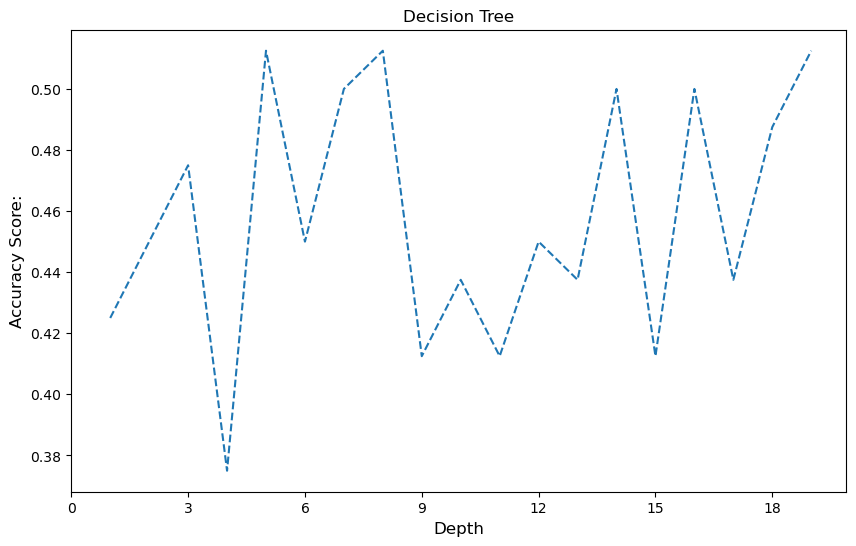

In [20]:
error=[]
max_accu=0
k_max=0
for k in range(1,20):
    dtc = DecisionTreeClassifier(max_depth=k,min_samples_leaf= 5, min_samples_split=20,max_leaf_nodes= 50,splitter='random')
    dtc.fit(X_train, y_train)
    y_pred_dtc = dtc.predict(X_test)
    accuracy_dtc = accuracy_score(y_test, y_pred_dtc)
    if(max_accu<accuracy_dtc):
        k_max=k
    max_accu=max(accuracy_dtc,max_accu)
    error.append(accuracy_dtc)
print("Max accuracy is:",max_accu,"For depth=",k_max)
plt.figure(figsize=(10,6))
plt.plot(range(1,20),error,linestyle='dashed')
ticks=np.arange(0, 20, 3)
plt.xticks(ticks)
plt.ylabel('Accuracy Score:', fontsize=12)
plt.xlabel('Depth', fontsize=12)
plt.title('Decision Tree')
plt.show()



In [21]:
accuracy_dtc=max_accu
dtc = DecisionTreeClassifier(max_depth=k_max,min_samples_leaf= 5, min_samples_split=20,max_leaf_nodes= 50,splitter='random')
dtc.fit(X_train, y_train)
y_pred_dtc = dtc.predict(X_test)
conf_matrix_dtc = confusion_matrix(y_test, y_pred_dtc)
print(classification_report(y_test, y_pred_dtc,zero_division=0))
print("Confusion Matrix for modified kNN:")
print(conf_matrix_knn)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         3
           5       0.45      0.36      0.40        25
           6       0.44      0.59      0.51        34
           7       0.27      0.29      0.28        14
           8       0.00      0.00      0.00         3

    accuracy                           0.41        80
   macro avg       0.19      0.21      0.20        80
weighted avg       0.38      0.41      0.39        80

Confusion Matrix for modified kNN:
[[ 0  0  1  0  0  0]
 [ 0  0  2  1  0  0]
 [ 0  0 17 14  1  0]
 [ 0  0  4 21  3  0]
 [ 0  0  0  8  4  0]
 [ 0  0  0  4  0  0]]


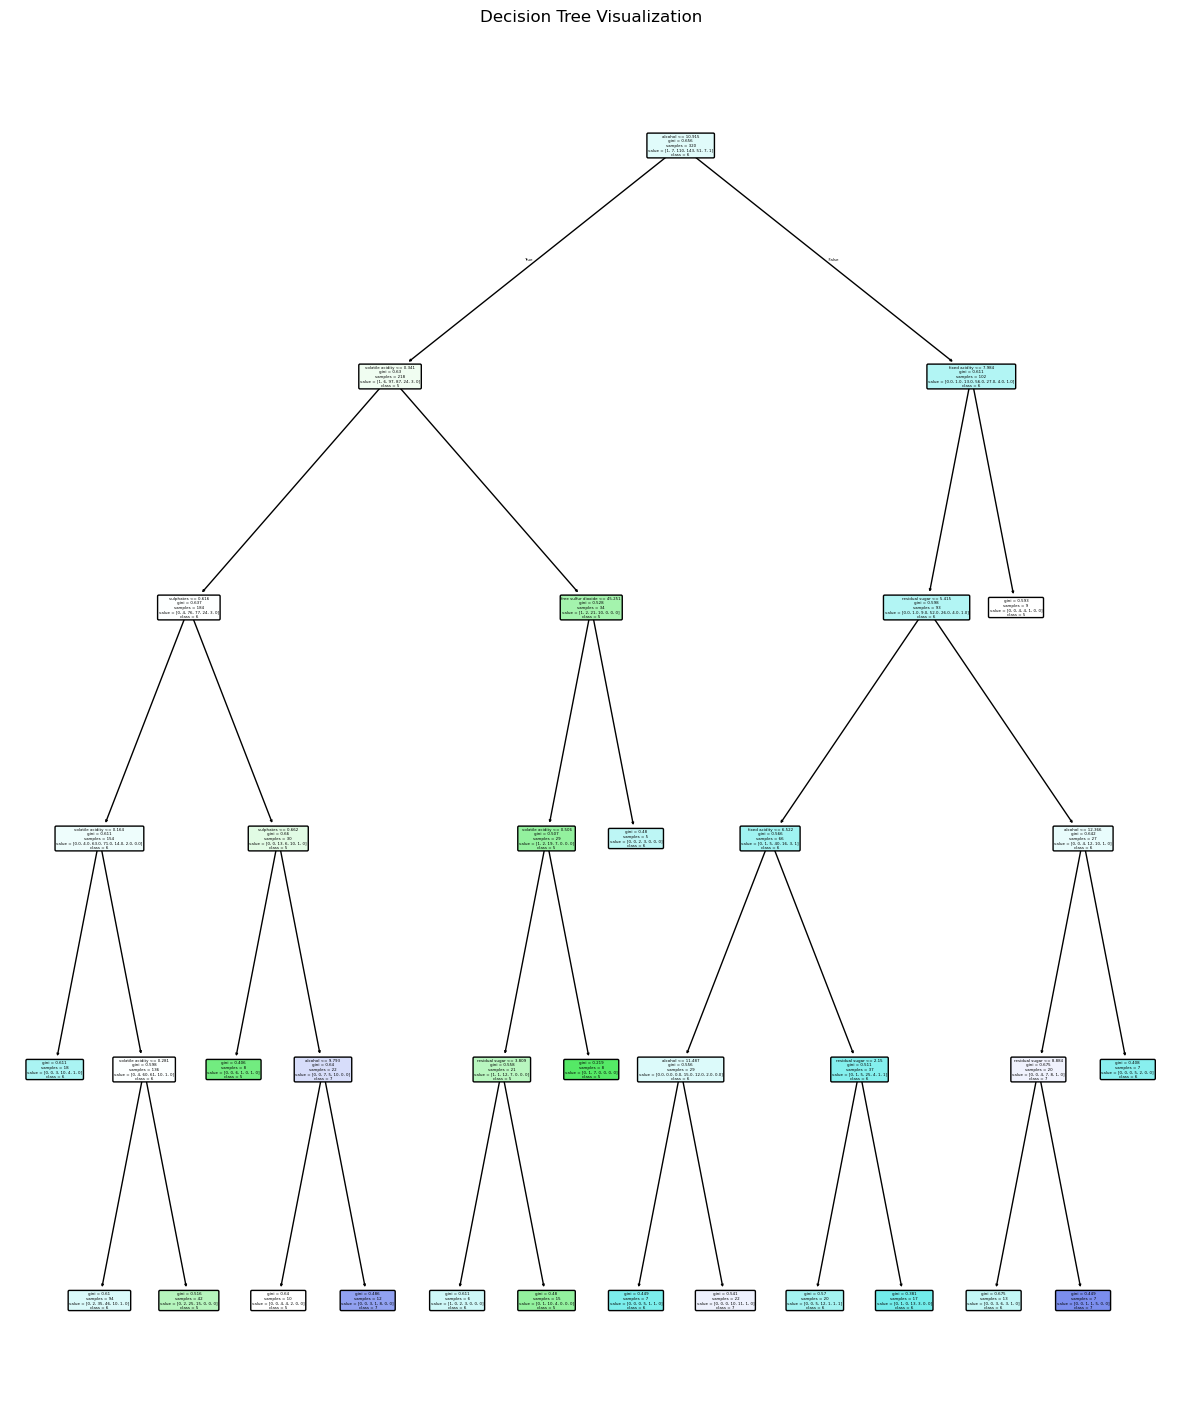

In [22]:
# Ploting the decision tree

plt.figure(figsize=(15, 18))
class_names = [str(cls) for cls in dtc.classes_]

plot_tree(dtc, feature_names=X.columns, class_names=class_names, filled=True, rounded=True)
plt.title('Decision Tree Visualization')
plt.savefig('tree.pdf')


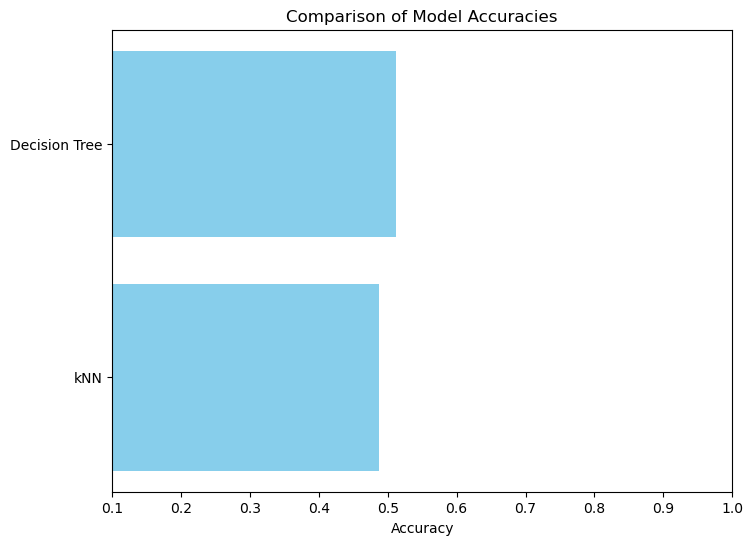

In [23]:
#comparing using box plot
models = ['kNN','Decision Tree']
accuracies = [accuracy_knn, accuracy_dtc]

plt.figure(figsize=(8, 6))
plt.barh(models, accuracies, color='skyblue')
plt.xlabel('Accuracy')
plt.title('Comparison of Model Accuracies')
plt.xlim([0.1, 1.0])
plt.show()

# Task 3: Clustering

In [24]:
sample3=data[~data.isnull().any(axis=1)].sample(600,random_state=42)
sample3.to_csv('s4098655-A2SampleThree.csv',sep=';',index=False)
sample3 = pd.read_csv('s4098655-A2SampleThree.csv', sep = ';')
sample3 = sample3.apply(pd.to_numeric)


In [25]:
sample3.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.5,0.19,0.49,1.6,0.047,42.0,140.0,0.99320,3.40,0.47,10.7,6
1,6.6,0.16,0.34,1.1,0.037,41.0,115.0,0.98990,3.01,0.68,12.0,6
2,6.7,0.21,0.42,9.1,0.049,31.0,150.0,0.99530,3.12,0.74,9.9,7
3,7.0,0.16,0.36,2.6,0.029,28.0,98.0,0.99126,3.11,0.37,11.2,7
4,6.4,0.24,0.27,1.5,0.040,35.0,105.0,0.98914,3.13,0.30,12.4,6


In [26]:
X = sample3.drop(columns=['quality'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## k-Means 

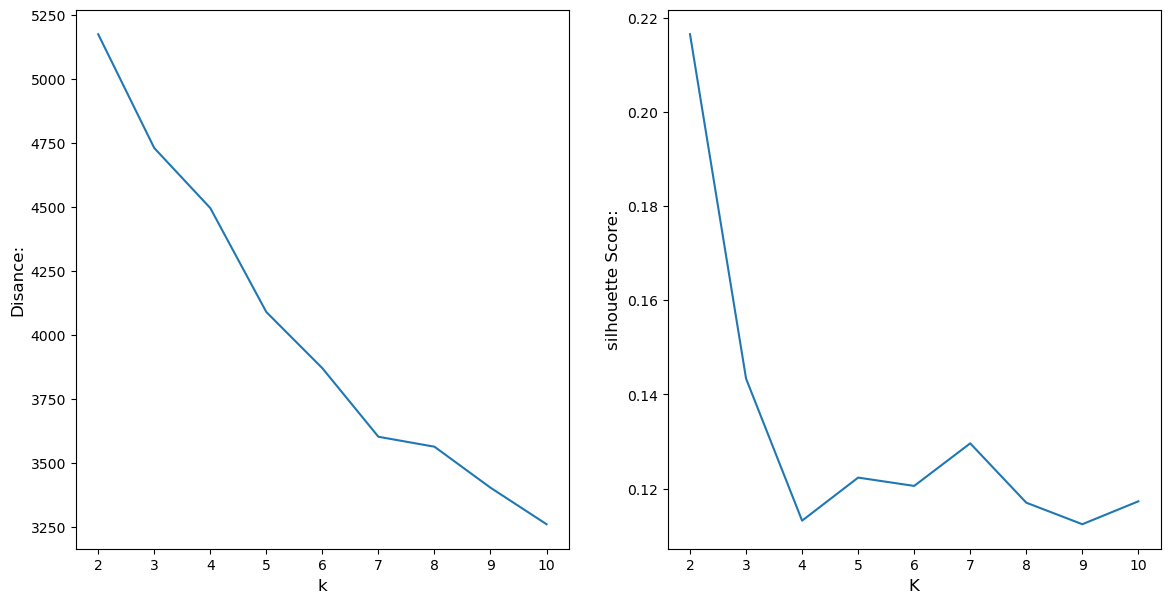

In [27]:
dist=[]
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(X_scaled)
    cluster_labels = kmeans.labels_
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    dist.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_avg)
#plotting wss vs k and silhouette score vs k
fig = plt.figure(figsize=(14,7))
fig.add_subplot(121)
plt.plot(range(2,11), dist)
ticks=np.arange(2, 11, 1)
plt.ylabel('Disance:', fontsize=12)
plt.xlabel('k', fontsize=12)
plt.xticks(ticks)
fig.add_subplot(122)
plt.plot(range(2,11),silhouette_scores)
plt.ylabel('silhouette Score:', fontsize=12)
plt.xlabel('K', fontsize=12)
plt.show()


In [28]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)
cluster_labels = kmeans.labels_
# Calculate metrics
kmeans_silhouette = silhouette_score(X_scaled, cluster_labels)
kmeans_ch = calinski_harabasz_score(X_scaled, cluster_labels)
kmeans_db = davies_bouldin_score(X_scaled, cluster_labels)
print("silhouette_score:",kmeans_silhouette)
print("calinski_harabasz_score:",kmeans_ch)
print("davies_bouldin_score:",kmeans_db)

silhouette_score: 0.21645081487959894
calinski_harabasz_score: 164.80127507573837
davies_bouldin_score: 1.7747196112762174


## DBSCAN & comparison 

Maximum Silhouette Score: 0.5156629555602997
Best epsilon (eps): 4.212105263157895
Best min_samples: 2


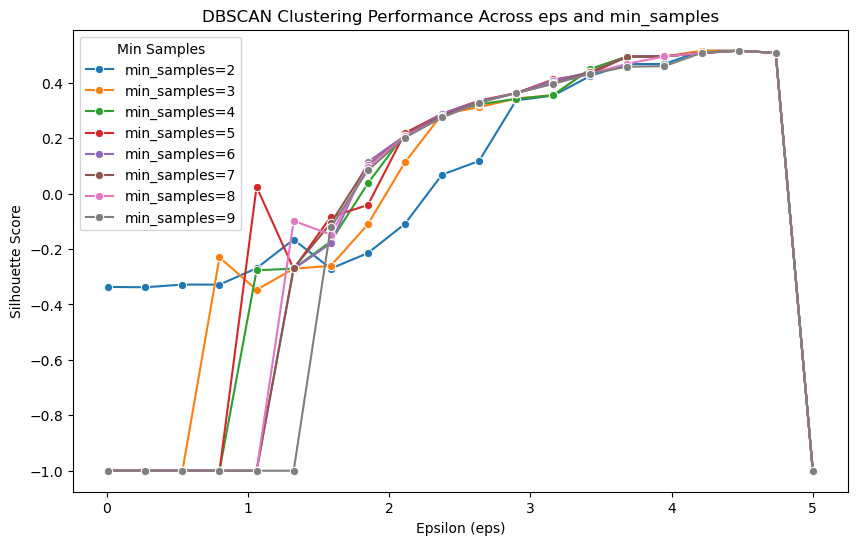

In [29]:
eps_values = np.linspace(0.01, 5, num=20)
min_samples_values = np.arange(2, 10, step=1)
dbscan_scores = {min_samples: [] for min_samples in min_samples_values}



# To find the best value
max_score = -1
best_eps = None
best_min_samples = None

combination = list(itertools.product(eps_values, min_samples_values))

# Loop through each combination of eps and min_samples
for eps, min_samples in combination:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan.fit(X_scaled)
    cluster_labels = dbscan.labels_

    # Calculate Silhouette Score for DBSCAN if more than 1 cluster is formed
    if len(set(cluster_labels)) > 1:  # Check if there is more than 1 cluster
        silhouette_avg = silhouette_score(X_scaled, cluster_labels)
        dbscan_scores[min_samples].append(silhouette_avg)


        if silhouette_avg > max_score:
            max_score = silhouette_avg
            best_eps = eps
            best_min_samples = min_samples
    else:
        dbscan_scores[min_samples].append(-1)  # Append -1 for cases with only 1 cluster

# Plotting the results using a line plot
plt.figure(figsize=(10, 6))

for min_samples, scores in dbscan_scores.items():
    sns.lineplot(x=eps_values, y=scores, marker='o', label=f'min_samples={min_samples}')
print(f"Maximum Silhouette Score: {max_score}")
print(f"Best epsilon (eps): {best_eps}")
print(f"Best min_samples: {best_min_samples}")
plt.xlabel('Epsilon (eps)')
plt.ylabel('Silhouette Score')
plt.title('DBSCAN Clustering Performance Across eps and min_samples')
plt.legend(title='Min Samples')
plt.show()



In [30]:
#using the best paramaters
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan.fit(X_scaled)
cluster_labels = dbscan.labels_
dbscan_silhouette = silhouette_score(X_scaled, cluster_labels)
dbscan_ch = calinski_harabasz_score(X_scaled, cluster_labels)
dbscan_db = davies_bouldin_score(X_scaled, cluster_labels)
print("silhouette_score:",dbscan_silhouette)
print("calinski_harabasz_score:",dbscan_ch)
print("davies_bouldin_score:",dbscan_db)


silhouette_score: 0.5156629555602997
calinski_harabasz_score: 7.332429925012768
davies_bouldin_score: 1.4388362874914498


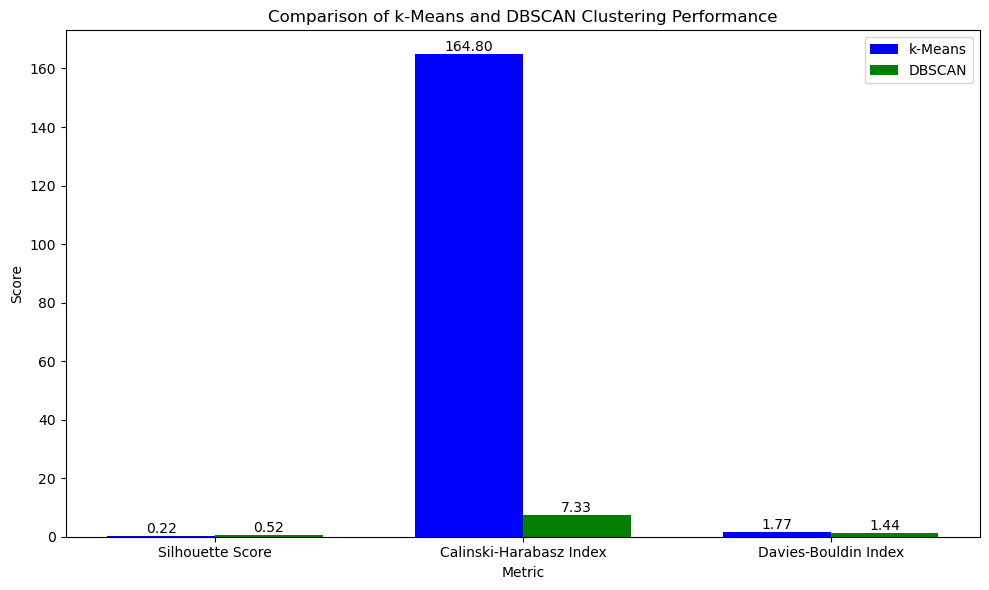

In [31]:
#comparison of kmeans and dbscans
metrics = ['Silhouette Score', 'Calinski-Harabasz Index', 'Davies-Bouldin Index']
kmeans_scores = [kmeans_silhouette, kmeans_ch, kmeans_db]
dbscan_scores = [dbscan_silhouette, dbscan_ch, dbscan_db]

x = np.arange(len(metrics))  # label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, kmeans_scores, width, label='k-Means', color='b')
bars2 = ax.bar(x + width/2, dbscan_scores, width, label='DBSCAN', color='g')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Comparison of k-Means and DBSCAN Clustering Performance')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

def add_labels(bars):
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}', ha='center', va='bottom')

add_labels(bars1)
add_labels(bars2)
plt.tight_layout()
plt.show()